# Gemma 3 vs Gemma 4: Road Sign Text Recognition
**CS153 Computer Vision Final Project**
**Janav Shah & Florence Lin**

This notebook walks through our full evaluation pipeline comparing two Google Gemma vision language models on the US Traffic Sign Classification dataset. For full instructions on setting up the necessary environment, installing dependencies, and downloading the Kaggle dataset, reference the README.md.

In [1]:
import os, sys, re, json
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
from PIL import Image

PROJECT_ROOT = "/cs/cs153/projects/jshah/cv153_final_project"
sys.path.insert(0, PROJECT_ROOT)
from config import (
    DS1_LABELS, PROCESSED_DIR, PREDS_DIR, METRICS_DIR,
    TEXT_SIGNS, PROMPTS, GEMMA3_MODEL_ID, GEMMA4_MODEL_ID
)

print("Setup complete.")
print(f"Gemma 3: {GEMMA3_MODEL_ID}")
print(f"Gemma 4: {GEMMA4_MODEL_ID}")

Setup complete.
Gemma 3: google/gemma-3-4b-it
Gemma 4: google/gemma-4-E4B-it


## 1. Dataset Overview

This section provides an overview of the the Traffic Sign Classification Dataset compared to each example's ground truth lables using 5 randomly selected classes. As detailed in the README.md, the dataset contains 58 classes and 171 total images. 

Total classes: 58
Eval images: 171
Text signs: 56 (32.7%)
Symbol signs: 115 (67.3%)


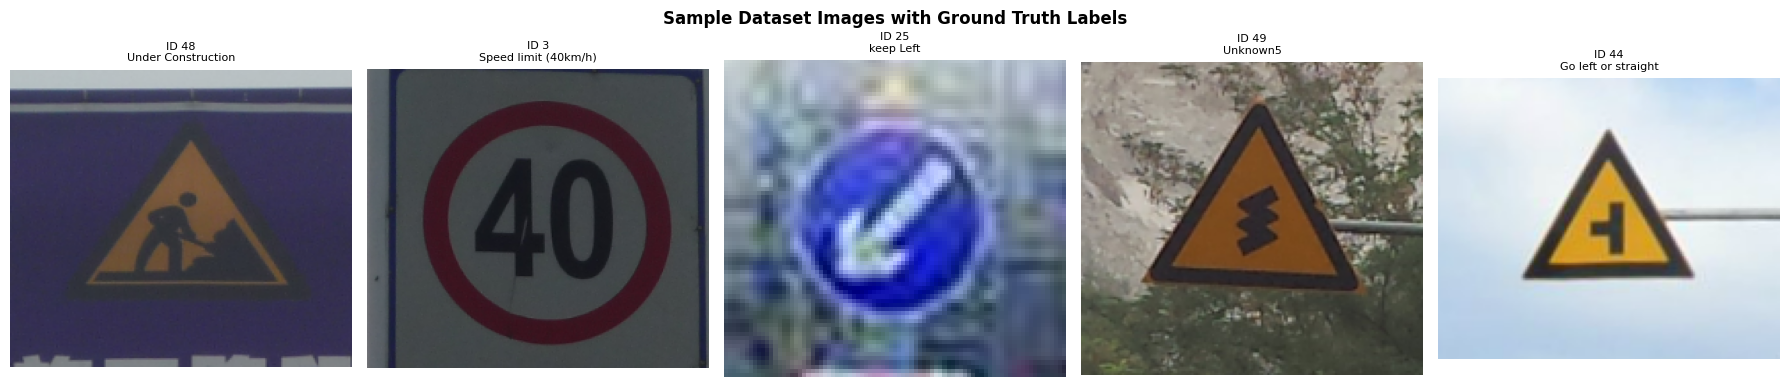

In [2]:
meta_df   = pd.read_csv(os.path.join(PROCESSED_DIR, "eval_metadata.csv"))
labels_df = pd.read_csv(DS1_LABELS)

print(f"Total classes: {len(labels_df)}")
print(f"Eval images: {len(meta_df)}")
print(f"Text signs: {meta_df['label_name'].isin(TEXT_SIGNS).sum()} ({meta_df['label_name'].isin(TEXT_SIGNS).mean()*100:.1f}%)")
print(f"Symbol signs: {(~meta_df['label_name'].isin(TEXT_SIGNS)).sum()} ({(~meta_df['label_name'].isin(TEXT_SIGNS)).mean()*100:.1f}%)")

sample = meta_df.sample(5, random_state=42)
fig, axes = plt.subplots(1, 5, figsize=(18, 4))
for ax, (_, row) in zip(axes, sample.iterrows()):
    img = Image.open(row["image_path"]).convert("RGB")
    ax.imshow(img)
    ax.set_title(f"ID {row['class_id']}\n{row['label_name']}", fontsize=8)
    ax.axis("off")
fig.suptitle("Sample Dataset Images with Ground Truth Labels", fontsize=12, fontweight="bold")
plt.tight_layout()
plt.show()

## 2. Models

We are comparing Gemma 3 and Gemma 4 for this project. Below details each model's HuggingFace id, parameters, architecture, strength, and access type. 

In [3]:
models = {
    "Gemma 3": {
        "id": "google/gemma-3-4b-it",
        "parameters": "4 Billion",
        "architecture": "Encoder-decoder VLM",
        "strength": "Precise text extraction",
        "access": "HuggingFace (gated)",
    },
    "Gemma 4": {
        "id": "google/gemma-4-E4B-it",
        "parameters": "E4B (efficient 4B)",
        "architecture": "Efficient multimodal",
        "strength": "Semantic understanding",
        "access": "HuggingFace",
    },
}

for name, info in models.items():
    print(f"\n{name}")
    print("-" * 35)
    for k, v in info.items():
        print(f"  {k:<15} {v}")


Gemma 3
-----------------------------------
  id              google/gemma-3-4b-it
  parameters      4 Billion
  architecture    Encoder-decoder VLM
  strength        Precise text extraction
  access          HuggingFace (gated)

Gemma 4
-----------------------------------
  id              google/gemma-4-E4B-it
  parameters      E4B (efficient 4B)
  architecture    Efficient multimodal
  strength        Semantic understanding
  access          HuggingFace


## 3. Pipeline Demo

The cell below demonstrates the pipeline we will use to pass the same image and prompt into each model. Each model will return a string which we evaluate against the ground truth using BLEU evalauation metric. 

The first prompt targets text extraction of the signs containing texts: "What text is written on this road sign? Reply with only the text you see." The second prompt targets semantic meaning: "What does this road sign mean? Reply with only one short sentence". 


Demo image: speed limit (80km/h)
Prompt: What text is written on this road sign? Reply with only the text you see, nothing else.




[transformers] `torch_dtype` is deprecated! Use `dtype` instead!


Loading weights:   0%|          | 0/883 [00:00<?, ?it/s]

[transformers] The following generation flags are not valid and may be ignored: ['top_p', 'top_k']. Set `TRANSFORMERS_VERBOSITY=info` for more details.


Gemma 3 output: 80



Loading weights:   0%|          | 0/2076 [00:00<?, ?it/s]

Gemma 4 output: 80


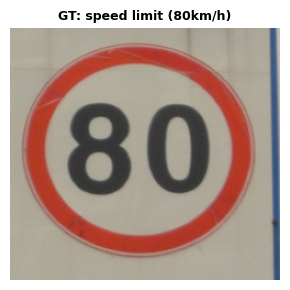


Ground Truth:speed limit (80km/h)
Gemma 3:80
Gemma 4:80


In [4]:
import torch
import gc
from transformers import AutoProcessor, AutoModelForImageTextToText

CACHE_DIR = f"/tmp/{os.environ.get('USER','user')}/hf-cache/hub"
DEVICE = "cuda:0"

def infer(processor, model, image, prompt):
    messages = [{"role": "user", "content": [{"type": "image", "image": image},{"type": "text",  "text": prompt},]}]
    inputs = processor.apply_chat_template(messages, add_generation_prompt=True,tokenize=True, return_dict=True, return_tensors="pt",)
    inputs = {k: v.to(model.device) if hasattr(v, "to") else v for k, v in inputs.items()}
    with torch.inference_mode():
        out = model.generate(**inputs, max_new_tokens=64, do_sample=False)
    prompt_len = inputs["input_ids"].shape[-1]
    return processor.decode(out[0][prompt_len:], skip_special_tokens=True).strip()

# Pick one demo image
demo_row = meta_df[meta_df["label_name"].str.contains("Speed limit", case=False)].iloc[0]
demo_img  = Image.open(demo_row["image_path"]).convert("RGB")
demo_prompt = PROMPTS["text_extraction"]

print(f"Demo image: {demo_row['label_name']}")
print(f"Prompt: {demo_prompt}\n")

# Run Gemma 3
print()
proc3 = AutoProcessor.from_pretrained(GEMMA3_MODEL_ID, cache_dir=CACHE_DIR)
model3 = AutoModelForImageTextToText.from_pretrained(GEMMA3_MODEL_ID, device_map=DEVICE, torch_dtype=torch.bfloat16, cache_dir=CACHE_DIR).eval()
g3_out = infer(proc3, model3, demo_img, demo_prompt)
print(f"Gemma 3 output: {g3_out}")

# Free GPU memory
del model3
gc.collect()
torch.cuda.empty_cache()

# Run Gemma 4
print()
proc4 = AutoProcessor.from_pretrained(GEMMA4_MODEL_ID, cache_dir=CACHE_DIR)
model4 = AutoModelForImageTextToText.from_pretrained(GEMMA4_MODEL_ID, device_map=DEVICE, torch_dtype=torch.bfloat16, cache_dir=CACHE_DIR).eval()
g4_out  = infer(proc4, model4, demo_img, demo_prompt)
print(f"Gemma 4 output: {g4_out}")

# Free GPU memory
del model4
gc.collect()
torch.cuda.empty_cache()

# Show image + results
fig, ax = plt.subplots(1, 1, figsize=(3, 3))
ax.imshow(demo_img)
ax.set_title(f"GT: {demo_row['label_name']}", fontsize=9, fontweight="bold")
ax.axis("off")
plt.tight_layout()
plt.show()

print(f"\nGround Truth:{demo_row['label_name']}")
print(f"Gemma 3:{g3_out}")
print(f"Gemma 4:{g4_out}")

## 4. Text Extraction Results

This cell scores each model's text extraction predictions against the ground truth label using two metrics: exact match and BLEU score. Outputs are first normalized by lowercasing and removing punctuation before comparison.

Exact match checks whether the normalized ground truth appears in the normalized prediction, with special handling for speed limit signs where a numeric match (e.g. "30" in "30 km/h") is sufficient.  BLEU score is computed using NLTK's sentence_bleu with smoothing to handle short outputs. 

Results are broken down by sign type (text vs. symbol). The summary table below reports the exact match percentage average BLEU score for each model across all signs, text-only signs, and symbol-only signs.

In [5]:
from nltk.translate.bleu_score import sentence_bleu, SmoothingFunction
_sf = SmoothingFunction().method1

def norm(text):
    text = str(text).lower()
    text = re.sub(r"[^\w\s]", "", text)
    return re.sub(r"\s+", " ", text).strip()

def exact_match(pred, label):
    if "km/h" in str(label).lower():
        nums = re.findall(r"\d+", str(label))
        return any(n in str(pred) for n in nums)
    return norm(label) in norm(str(pred))

def bleu(pred, ref):
    r = norm(ref).split(); h = norm(str(pred)).split()
    return round(sentence_bleu([r], h, smoothing_function=_sf), 4) if h and r else 0.0

def score_df(df, model_name):
    if "pred_1" in df.columns and "prediction" not in df.columns:df = df.rename(columns={"pred_1": "prediction"})
    df = df.copy()
    df["model"] = model_name
    df["sign_type"] = df["label_name"].apply(lambda x: "text" if x in TEXT_SIGNS else "symbol")
    df["exact_match"] = df.apply(lambda r: exact_match(r["prediction"], r["label_name"]), axis=1)
    df["bleu_score"] = df.apply(lambda r: bleu(r["prediction"], r["label_name"]), axis=1)
    return df

def summarize(df):
    rows = []
    for subset, sub in [("All Signs", df),("Text Signs",   df[df["sign_type"]=="text"]),("Symbol Signs", df[df["sign_type"]=="symbol"])]:
        rows.append({
            "Model": df["model"].iloc[0],
            "Subset":subset,
            "N": len(sub),
            "Exact Match %": round(sub["exact_match"].mean() * 100, 1),
            "Avg BLEU": round(sub["bleu_score"].mean(), 4),
        })
    return pd.DataFrame(rows)
g3_text = score_df(pd.read_csv(os.path.join(PREDS_DIR, "gemma3_text_extraction.csv")), "Gemma 3")
g4_text = score_df(pd.read_csv(os.path.join(PREDS_DIR, "gemma4_text_extraction.csv")), "Gemma 4")
text_summary = pd.concat([summarize(g3_text), summarize(g4_text)], ignore_index=True)
print(text_summary.to_string(index=False))

  Model       Subset   N  Exact Match %  Avg BLEU
Gemma 3    All Signs 171           21.1    0.0269
Gemma 3   Text Signs  56           60.7    0.0373
Gemma 3 Symbol Signs 115            1.7    0.0218
Gemma 4    All Signs 171           17.5    0.0027
Gemma 4   Text Signs  56           53.6    0.0064
Gemma 4 Symbol Signs 115            0.0    0.0009


This cell visualizes the text extraction scoring results as a grouped bar chart, comparing Gemma 3 and Gemma 4 across all signs, text-only signs, and symbol-only signs. The left plot shows the exact match percentage and the right shows the average BLEU score for each model and subset. 

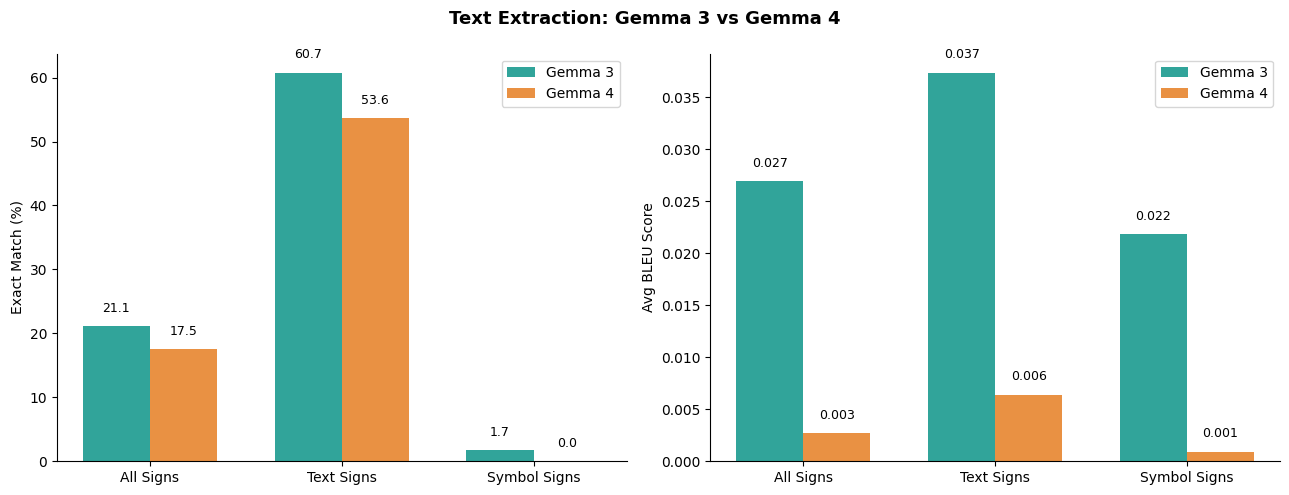

In [10]:
subsets = ["All Signs", "Text Signs", "Symbol Signs"]
colors  = {"Gemma 3": "#0D9488", "Gemma 4": "#E67E22"}
x, w    = np.arange(len(subsets)), 0.35
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle("Text Extraction: Gemma 3 vs Gemma 4", fontsize=13, fontweight="bold")
metrics = [("Exact Match %", "Exact Match (%)"), ("Avg BLEU", "Avg BLEU Score")]

for idx, (metric, ylabel) in enumerate(metrics):
    ax = axes[idx]
    max_val = text_summary[metric].max()
    for i, model in enumerate(["Gemma 3", "Gemma 4"]):
        vals = [text_summary[(text_summary["Model"]==model) & (text_summary["Subset"]==s)][metric].values[0] for s in subsets]
        bars = ax.bar(x + i*w, vals, w, label=model, color=colors[model], alpha=0.85)
        for bar, val in zip(bars, vals):
            ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + max_val*0.03, f"{val:.1f}" if metric=="Exact Match %" else f"{val:.3f}", ha="center", va="bottom", fontsize=9)
    
    ax.set_xticks(x + w/2)
    ax.set_xticklabels(subsets)
    ax.set_ylabel(ylabel)
    ax.legend()
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.show()

## 5. Mean Task Results

This cell loads and scores each model's responses to the semantic prompt ("What does this road sign mean? Reply with only one short sentence") against the ground truth label using the same exact match and BLEU scoring pipeline as the text extraction task. Our results are broken down by sign type and summarized across all signs, text only signs, and symbol only signs. Our analysis is in the project writeup.

In [11]:
g3_mean = score_df(pd.read_csv(os.path.join(PREDS_DIR, "gemma3_meaning.csv")),"Gemma 3")
g4_mean = score_df(pd.read_csv(os.path.join(PREDS_DIR, "gemma4_meaning.csv")),"Gemma 4")
mean_summary = pd.concat([summarize(g3_mean), summarize(g4_mean)], ignore_index=True)
print(mean_summary.to_string(index=False))

  Model       Subset   N  Exact Match %  Avg BLEU
Gemma 3    All Signs 171           23.4    0.0227
Gemma 3   Text Signs  56           66.1    0.0241
Gemma 3 Symbol Signs 115            2.6    0.0219
Gemma 4    All Signs 171           21.6    0.0235
Gemma 4   Text Signs  56           57.1    0.0307
Gemma 4 Symbol Signs 115            4.3    0.0200


This cell visualizes the meaning task scoring results in a bar chart by comparing Gemma 3 and Gemma 4 across all signs, text-only signs, and symbol-only signs. The left plot displays exact match percentage and the right displays average BLEU score for each model and subset. Our analysis is done in the project writeup.

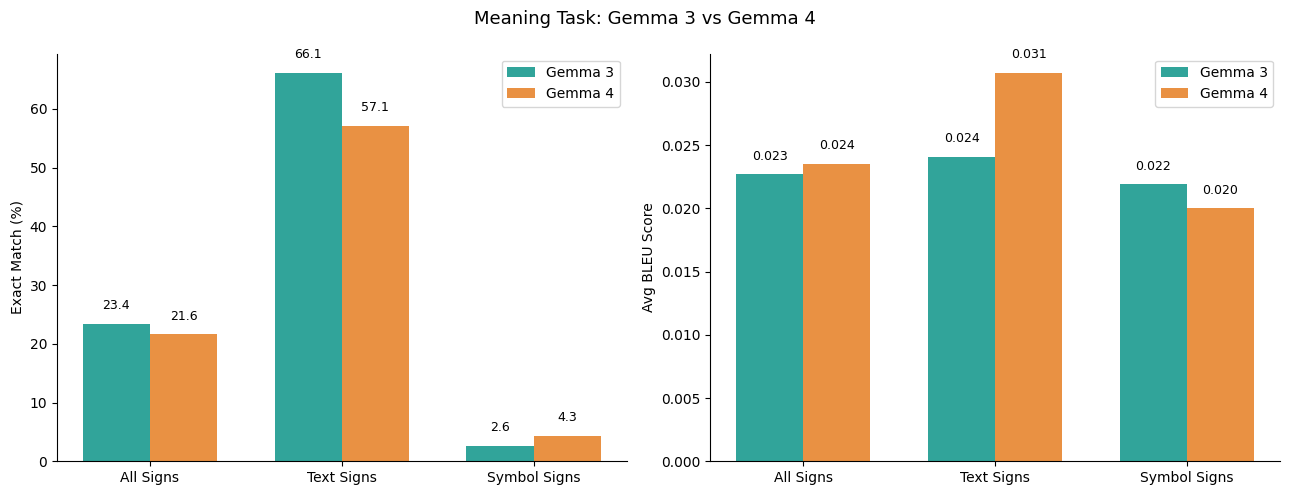

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle("Meaning Task: Gemma 3 vs Gemma 4", fontsize=13)
metrics = [("Exact Match %", "Exact Match (%)"), ("Avg BLEU", "Avg BLEU Score")]

for idx, (metric, ylabel) in enumerate(metrics):
    ax = axes[idx]
    max_val = mean_summary[metric].max()
    for i, model in enumerate(["Gemma 3", "Gemma 4"]):
        vals = [mean_summary[(mean_summary["Model"]==model) & (mean_summary["Subset"]==s)][metric].values[0] for s in subsets]
        bars = ax.bar(x + i*w, vals, w, label=model, color=colors[model], alpha=0.85)
        for bar, val in zip(bars, vals):
            ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + max_val*0.03, f"{val:.1f}" if metric=="Exact Match %" else f"{val:.3f}", ha="center", va="bottom", fontsize=9)
    ax.set_xticks(x + w/2)
    ax.set_xticklabels(subsets)
    ax.set_ylabel(ylabel)
    ax.legend()
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
plt.tight_layout()
plt.show()

## 6. Scenario Prompts & BERTScore

Each model's BERTScore F1 was precomputed for each model and scenario combination using evaluate_bertscore.py, which scores each model's predictions against a set of reference answers using contextual embeddings from a pretrained BERT model. evaluate_bertscore.py then saves each result into a directory (ignored in gitignore).

This cell loads the precomputed summary and maps each scenario to a readable lable. The following three prompts below were evaluted and displayed in a summary table: 
- **New Driver:** "You are a new driver and see this sign at an intersection. What action do you take?"
- **Highway:** "You are driving at highway speed and this sign appears ahead. What does it require you to do?"
- **Explain:** "You are a passenger explaining this sign to someone who has never driven before. What does it mean and why does it matter?"

In [13]:
bert_df = pd.read_csv(os.path.join(METRICS_DIR, "bertscore_summary.csv"))

scenario_labels = {
    "scenario_new_driver": "New Driver",
    "scenario_highway": "Highway",
    "scenario_explain": "Explain",
}
bert_df["scenario_label"] = bert_df["scenario"].map(scenario_labels)
print(bert_df[["model","scenario_label","n_images","avg_bertscore_f1"]].to_string(index=False))

 model scenario_label  n_images  avg_bertscore_f1
gemma3     New Driver       189            0.8949
gemma3        Highway       189            0.9037
gemma3        Explain       189            0.8938
gemma4     New Driver       189            0.8917
gemma4        Highway       189            0.8938
gemma4        Explain       189            0.8943


This cell visualizes the BERTScore F1 results loaded from bertscore_summary.csv (generated by evaluate_bertscore.py) as a bar chart that Gemma 3 and Gemma 4 across the three scenario prompts. The y-axis is scaled between 0.85 and 0.92 to highlight the relatively narrow but meaningful differences in semantic similarity across models and scenarios.

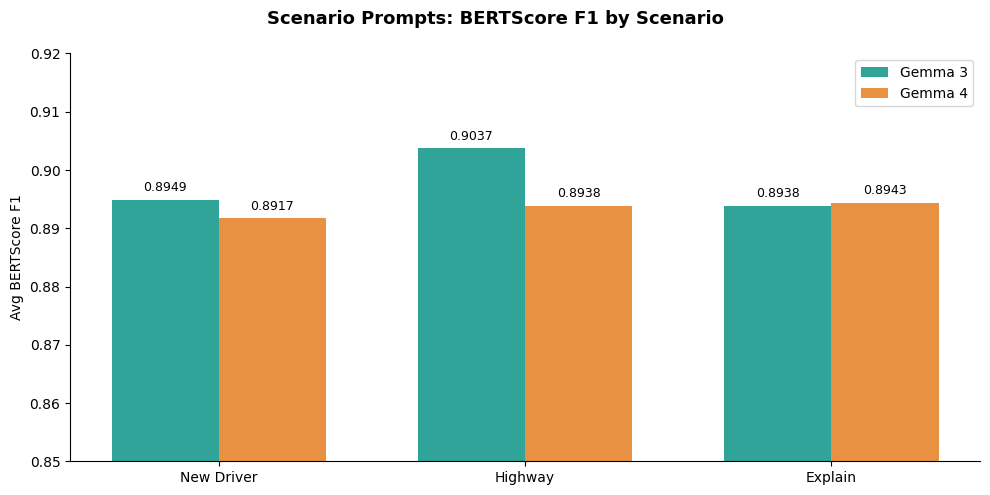

In [14]:
scenario_names = ["New Driver", "Highway", "Explain"]
x2, w2 = np.arange(len(scenario_names)), 0.35

fig, ax = plt.subplots(figsize=(10, 5))
fig.suptitle("Scenario Prompts: BERTScore F1 by Scenario", fontsize=13, fontweight="bold")

for i, model in enumerate(["gemma3", "gemma4"]):
    vals = [bert_df[(bert_df["model"]==model) & (bert_df["scenario_label"]==s)]["avg_bertscore_f1"].values[0] for s in scenario_names]
    bars = ax.bar(x2+i*w2, vals, w2, label="Gemma 3" if model=="gemma3" else "Gemma 4", color=colors["Gemma 3" if model=="gemma3" else "Gemma 4"], alpha=0.85)
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.001, f"{val:.4f}", ha="center", va="bottom", fontsize=9)
ax.set_xticks(x2+w2/2)
ax.set_xticklabels(scenario_names)
ax.set_ylabel("Avg BERTScore F1")
ax.set_ylim(0.85, 0.92)
ax.legend()
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
plt.tight_layout()
plt.show()

## 7. Failure Analysis

This failure analysis section categorizes each model's text extraction failures into the different types to identify where each model may not perform as well. Failure type counts and percentages are printed for each model.
- A prediction is labeled as correct if it passes the check for an exact match. 
- If the normalized output contains phrases like "no text" or "not visible" it is labled as refused (no text) which indicates that the model declined to extract any text. 
- Remaining incorrect predictions are labeled as hallucinated or wrong, which means the model generated a response with no real overlap with the ground truth.

In [15]:
def failure_type(pred, label):
    if exact_match(pred, label):
        return "correct"
    p = norm(str(pred))
    if "no text" in p or "not visible" in p:
        return "refused (no text)"
    if any(w in p for w in norm(str(label)).split() if len(w) > 3):
        return "partial match"
    return "hallucinated / wrong"

g3_text["failure_type"] = g3_text.apply(lambda r: failure_type(r["prediction"], r["label_name"]), axis=1)
g4_text["failure_type"] = g4_text.apply(lambda r: failure_type(r["prediction"], r["label_name"]), axis=1)

for name, df in [("Gemma 3", g3_text), ("Gemma 4", g4_text)]:
    print(f"\n{name}:")
    for k, v in df["failure_type"].value_counts().items():
        print(f"  {k:<30} {v:>4}  ({v/len(df)*100:.1f}%)")


Gemma 3:
  hallucinated / wrong             84  (49.1%)
  correct                          36  (21.1%)
  refused (no text)                35  (20.5%)
  partial match                    16  (9.4%)

Gemma 4:
  refused (no text)                96  (56.1%)
  hallucinated / wrong             45  (26.3%)
  correct                          30  (17.5%)


This cell shows example images for each failure type from Gemma 3's text sign predictions. Each image is annotated with its failure type, the ground truth label, and the first 40 characters of the model's output. Correct predictions are labeled in green and all failure types in red.

/tmp/ipykernel_26879/1593488589.py:19: UserWarning: Glyph 22823 (\N{CJK UNIFIED IDEOGRAPH-5927}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_26879/1593488589.py:19: UserWarning: Glyph 39376 (\N{CJK UNIFIED IDEOGRAPH-99D0}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_26879/1593488589.py:19: UserWarning: Glyph 36554 (\N{CJK UNIFIED IDEOGRAPH-8ECA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_26879/1593488589.py:19: UserWarning: Glyph 22580 (\N{CJK UNIFIED IDEOGRAPH-5834}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/cs/cs153/customenvs/jshah/cs153finalproject/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 22823 (\N{CJK UNIFIED IDEOGRAPH-5927}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/cs/cs153/customenvs/jshah/cs153finalproject/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 39376 (\N{CJK UNIFIED IDEOG

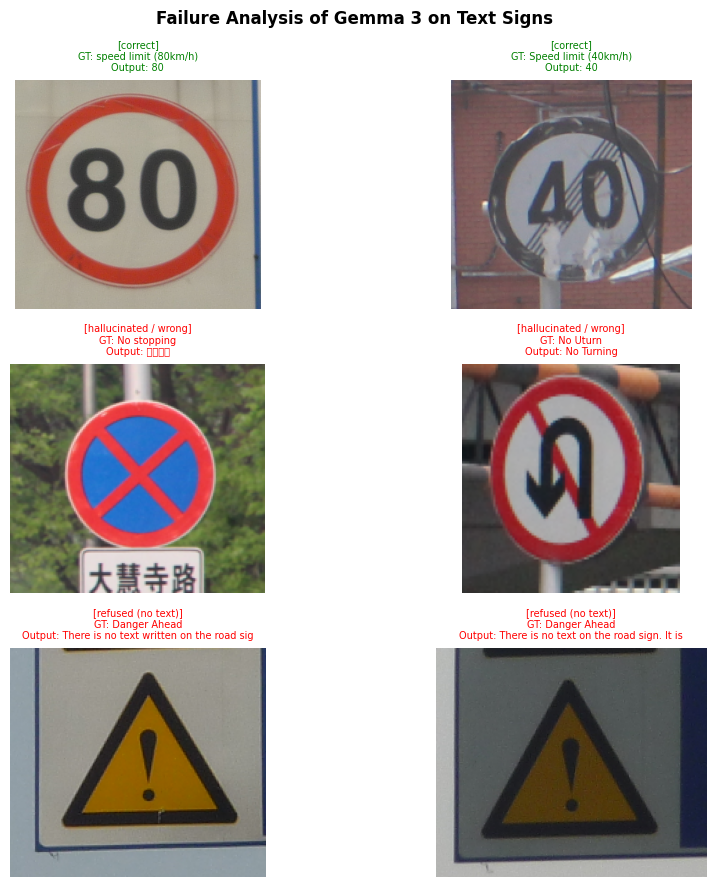

In [16]:
# Show example images for each failure type on text signs
text_g3 = g3_text[g3_text["sign_type"]=="text"].copy()
failure_types = ["correct", "partial match", "hallucinated / wrong", "refused (no text)"]
examples = {ft: text_g3[text_g3["failure_type"]==ft].head(2) for ft in failure_types if len(text_g3[text_g3["failure_type"]==ft]) > 0}
n = len(examples)
fig, axes = plt.subplots(n, 2, figsize=(10, n*3))
if n == 1: axes = axes.reshape(1, -1)
fig.suptitle("Failure Analysis of Gemma 3 on Text Signs", fontsize=12, fontweight="bold")

for row_i, (ft, rows) in enumerate(examples.items()):
    for col_i, (_, r) in enumerate(rows.iterrows()):
        ax = axes[row_i, col_i]
        img = Image.open(r["image_path"]).convert("RGB")
        ax.imshow(img)
        color = "green" if ft == "correct" else "red"
        ax.set_title(f"[{ft}]\nGT: {r['label_name']}\nOutput: {str(r['prediction'])[:40]}",
                     fontsize=7, color=color)
        ax.axis("off")
plt.tight_layout()
plt.show()